# Passenger Satisfaction Project
In this project, we will analyze a dataset of airline passenger satisfaction, going through the steps below.

**The four primary research questions the project aims to answer, based on the objectives of an Airline Customer Experience Manager, will be:**
1. What factors are most associated with passenger satisfaction?
2. Which customer groups are least satisfied?
3. How are factors most associated with passenger satisfaction, depending on different customer groups?
4. Are there redundant survey questions? Could the survey be simplified without losing information?

## 1. Setup Environment:
The first thing we'll need to do is load in the libraries and dataset we'll be using.

In [1]:
# import neccessary libraries
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
# import the dataset
raw_data = pd.read_excel("/kaggle/input/customer-satisfaction/satisfaction.xlsx")

**Inspect the first few rows:**

In [3]:
# view the first few rows
raw_data.head()

,id,satisfaction_v2,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,11112,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,110278,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,103199,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,47462,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,120011,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,...,4,2,2,0,2,4,2,5,0,0.0


## 2. Data Cleaning and Preprocessing:
Perform necessary data cleaning, before we start the analysis.

#### Create a Copy to Be Updated:
The original dataset will be preserved in a separate raw version, and all preprocessing steps will be performed on a working copy, to ensure reproducibility and data integrity.

In [4]:
# create working copy
data = raw_data.copy()

#### Make Sure that the Variables are Named Correctly and Usefully:
The column satisfaction_v2 will be renamed to satisfaction to improve clarity and consistency throughout the analysis.

In [5]:
# rename the "satisfaction_v2" column to "satisfaction"
data = data.rename(columns={"satisfaction_v2": "satisfaction"})

# verify the change
data.columns

Index(['id', 'satisfaction', 'Gender', 'Customer Type', 'Age',
       'Type of Travel', 'Class', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

### 2.1. Data Type Validation:
Verify that every column has the correct logical type for analysis.

**The dataset's data types will be inspected using data.dtypes to identify inconsistencies and incorrect type assignments.**

In [6]:
# view the data type of each column
data.dtypes

id                                     int64
satisfaction                          object
Gender                                object
Customer Type                         object
Age                                    int64
Type of Travel                        object
Class                                 object
Flight Distance                        int64
Seat comfort                           int64
Departure/Arrival time convenient      int64
Food and drink                         int64
Gate location                          int64
Inflight wifi service                  int64
Inflight entertainment                 int64
Online support                         int64
Ease of Online booking                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Cleanliness                            int64
Online boarding                        int64
Departure 

#### Convert the id Column Into a Non-Numeric Data Type:
The identifier column will be converted from numeric to string type, to prevent it from being treated as a quantitative variable in statistical analyses.

In [7]:
# convert the "id" column into string type
data["id"] = data["id"].astype(str)

# ensure that the "id" column is no longer numeric
data["id"].dtype

dtype('O')

#### Ensure Numeric Columns Are Numeric:
Sometimes numeric columns are loaded as object. In order to analyze them statistically, they should have a numeric data type.

**In this case, every column that has to be numeric, is already numeric.**

However, the "Arrival Delay in Minutes" column data type is float, while the "Departure Delay in Minutes" column, and all the other numeric columns, have a data type of int. 
Therefore, if all the non-missing values are actually whole numbers, we will convert the data type of the "Arrival Delay in Minutes" column to int (instead of float).

In [8]:
# check if all the non-missing values are whole numbers
# use the .any() method, instead of .all(), because missing values (if there are here), 
# are considered as None, which is always considered as False, in boolean conditions.
(data["Arrival Delay in Minutes"] % 1 > 0).any()

np.False_

**After checking, we can see that none of the numbers in the "Arrival Delay in Minutes" column have decimals, so we will convert the whole column to int data type.** If there are missing values (since we validate data types before dealing with missing values), we will convert the column to "Int64" data type (instead of "int64", which throws an error if missing values exist).

In [9]:
# check if there are any missing values 
int(data["Arrival Delay in Minutes"].isnull().sum())

393

In [10]:
# convert data type from float to int
data["Arrival Delay in Minutes"] = data["Arrival Delay in Minutes"].astype("Int64")

# ensure that the "Arrival Delay in Minutes" column has int data type now
data["Arrival Delay in Minutes"].dtype

Int64Dtype()

#### Convert Categorical Columns Properly:
Some columns can be analyzed more efficiently as categorical variables, rather than object.
This is better for memory efficiency, clear semantic meaning, and for grouping.

In [11]:
# define the list of columns that should be categorical
categorical_cols = ["satisfaction", "Gender", "Customer Type", "Type of Travel", "Class"]

# convert the columns to category data type
data[categorical_cols] = data[categorical_cols].astype("category")

# ensure that the listed columns data type has changed to category
data[categorical_cols].dtypes

satisfaction      category
Gender            category
Customer Type     category
Type of Travel    category
Class             category
dtype: object

#### Final Validation:

In [12]:
# view the data type of each column, again
data.dtypes

id                                     object
satisfaction                         category
Gender                               category
Customer Type                        category
Age                                     int64
Type of Travel                       category
Class                                category
Flight Distance                         int64
Seat comfort                            int64
Departure/Arrival time convenient       int64
Food and drink                          int64
Gate location                           int64
Inflight wifi service                   int64
Inflight entertainment                  int64
Online support                          int64
Ease of Online booking                  int64
On-board service                        int64
Leg room service                        int64
Baggage handling                        int64
Checkin service                         int64
Cleanliness                             int64
Online boarding                   

**After final validation, we can see that every column has the data type it should have.**

### 2.2. Dealing with Missing Values:

#### Check the Quantity of Missing values:

In [13]:
# get the number of missing data points per column
missing_value_counts = data.isnull().sum()
missing_value_counts

id                                     0
satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

In [14]:
# get the percentage of missing data points per column
missing_value_percentages = 100 * data.isnull().sum() / data.shape[0]
missing_value_percentages.name = "missing val %"
missing_value_percentages

id                                   0.000000
satisfaction                         0.000000
Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Seat comfort                         0.000000
Departure/Arrival time convenient    0.000000
Food and drink                       0.000000
Gate location                        0.000000
Inflight wifi service                0.000000
Inflight entertainment               0.000000
Online support                       0.000000
Ease of Online booking               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Cleanliness                          0.000000
Online boarding                   

**We can see that the only column with any missing values, is "Arrival Delay in Minutes".
We can also see that only ~0.3% of the values in that column are missing.
We can fill them by the median of the non-missing values in the same column.**

In [15]:
# replace all NA's in the only column with missing values, 
# by the median of the non-NA values in the same column
data["Arrival Delay in Minutes"] = \
data["Arrival Delay in Minutes"].fillna(data["Arrival Delay in Minutes"].median())

Make sure that no missing values have been left:

In [16]:
# make sure that no missing values have been left
int(data.isnull().sum().sum())

0

**No missing values left.**

### 2.3. Dealing with Duplicates:

Since multiple survey responses from the same passenger (not at the same time) are possible, we will only remove comletely duplicated rows, instead of just checking the id of the passenger. 

In [17]:
# check how many duplicated rows we have
int(data.duplicated().sum())

0

**After checking for duplicate records, none were found.**

### 2.4. Dealing with Outliers:

In [18]:
# find numeric columns
numeric_cols = data.select_dtypes(include="number").columns
numeric_cols

Index(['Age', 'Flight Distance', 'Seat comfort',
       'Departure/Arrival time convenient', 'Food and drink', 'Gate location',
       'Inflight wifi service', 'Inflight entertainment', 'Online support',
       'Ease of Online booking', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness', 'Online boarding',
       'Departure Delay in Minutes', 'Arrival Delay in Minutes'],
      dtype='object')

#### Find Rating and Non-Rating Numeric Columns:
Numeric variables will be separated into rating-based features and non-rating quantitative features, to allow tailored preprocessing strategies. Outlier detection strategies will only be applied to non-rating numeric variables.

**Find rating columns:**
In airline satisfaction datasets, service ratings are typically within a scale of 0-5, or 1-5.
Therefore, and since we now have only integer numeric columns (no floats), ratings outside these ranges, are not merely outliers, they are invalid.

In [19]:
# find numeric data 
numeric_only_data = data.select_dtypes(include="number")

# get a series of ratios - one ratio per column.
in_range_ratio = ((numeric_only_data >= 0) & (numeric_only_data <= 5)).mean()

# mark rating columns as those with ratios above or equal to the threshold of 0.95
rating_cols = in_range_ratio[in_range_ratio >= 0.95].index

# check if there are any invalid values in rating columns
print(1 - in_range_ratio[rating_cols]) 
print('\n')

print("List of rating columns:")
rating_cols.to_list()

Seat comfort                         0.0
Departure/Arrival time convenient    0.0
Food and drink                       0.0
Gate location                        0.0
Inflight wifi service                0.0
Inflight entertainment               0.0
Online support                       0.0
Ease of Online booking               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Cleanliness                          0.0
Online boarding                      0.0
dtype: Float64


List of rating columns:


['Seat comfort',
 'Departure/Arrival time convenient',
 'Food and drink',
 'Gate location',
 'Inflight wifi service',
 'Inflight entertainment',
 'Online support',
 'Ease of Online booking',
 'On-board service',
 'Leg room service',
 'Baggage handling',
 'Checkin service',
 'Cleanliness',
 'Online boarding']

Since no invalid ranking values were found, there is no need to clean or treat anything differently.

**Find non-rating numeric columns:**

In [20]:
# find non-rating numeric columns
non_rating_numeric_cols = numeric_cols[~numeric_cols.isin(rating_cols)]
non_rating_numeric_cols

Index(['Age', 'Flight Distance', 'Departure Delay in Minutes',
       'Arrival Delay in Minutes'],
      dtype='object')

#### Explore Distributions (Before Detecting Outliers):
We will only apply the following steps on non-rating numeric columns.

In [21]:
# inspect statistical measures of the relevant columns
data[non_rating_numeric_cols].describe()

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.0
mean,39.427957,1981.409055,14.713713,15.045465
std,15.119360,1027.115606,38.071126,38.416353
min,7.000000,50.000000,0.000000,0.0
25%,27.000000,1359.000000,0.000000,0.0
50%,40.000000,1925.000000,0.000000,0.0
75%,51.000000,2544.000000,12.000000,13.0
max,85.000000,6951.000000,1592.000000,1584.0


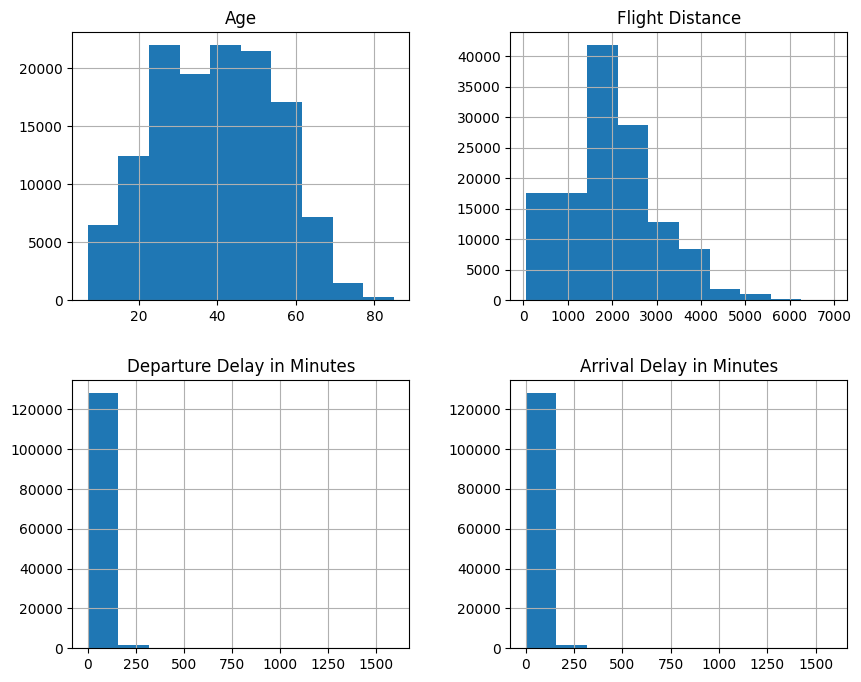

In [22]:
# visualize distributions
data[non_rating_numeric_cols].hist(figsize=(10, 8))
plt.show()

#### Detect Outliers:
We will do this by using the IQR method. Instead of doing column-by-column manually, we will do this for all non-rating numeric columns at once.

In [23]:
# find the IQR
Q1 = data[non_rating_numeric_cols].quantile(0.25)
Q3 = data[non_rating_numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# find the bounds, so any value outside of them, is an outlier
lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

In [24]:
# detect how many outliers per column
outliers_mask = (
    (data[non_rating_numeric_cols] < lower_bounds) |
    (data[non_rating_numeric_cols] > upper_bounds)
)

outlier_portion = outliers_mask.mean()
outlier_portion

Age                                0.0
Flight Distance               0.019872
Departure Delay in Minutes    0.139344
Arrival Delay in Minutes      0.134678
dtype: Float64

#### Interpret Before Reacting:

**Age -**
The age variable was inspected and found to fall within a realistic human age range (minimum = 7, maximum = 85). No outlier treatment is required.

**Flight Distance -**
the Flight Distance variable was examined for outliers using descriptive statistics and distribution visualization. Although the distribution is right-skewed, the maximum value (6,951 miles) falls within the realistic range for long-haul international flights. Therefore, no outlier treatment will be applied to this variable.

**Delays -** 
In the delay histograms, the tails are too thin to see them, so we cannot see if they are smooth or isolated spikes, so we will use several methods to check this. 

**Log Histograms:**

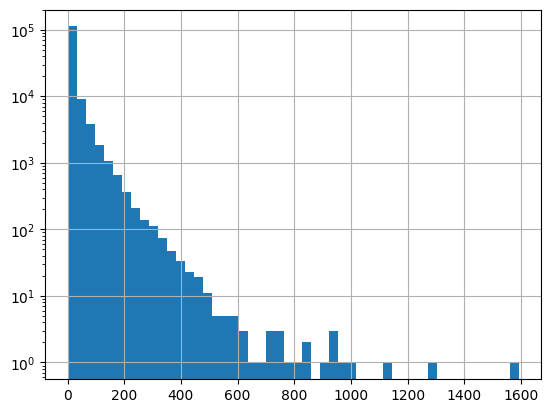

In [25]:
# log histogram - "Departure Delay in Minutes"
data["Departure Delay in Minutes"].hist(bins=50)
plt.yscale("log")
plt.show()

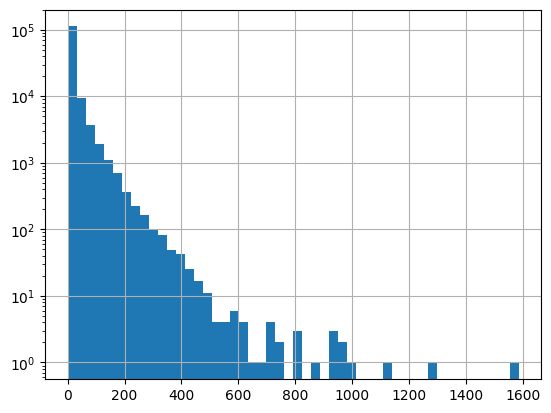

In [26]:
# log histogram - "Arrival Delay in Minutes"
data["Arrival Delay in Minutes"].hist(bins=50)
plt.yscale("log")
plt.show()

Now, as small-frequency bins are visible, we can see that the tails are almost smooth, no extreme isolated spikes.

**Zoom into the Right Tails:**

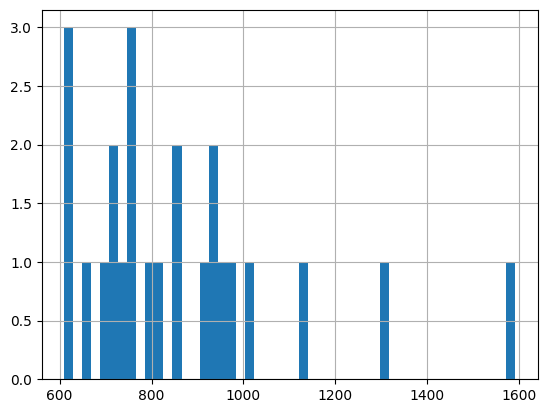

In [27]:
# zoom into the right tail - "Departure Delay in Minutes"
data[data["Departure Delay in Minutes"] > 600]["Departure Delay in Minutes"].hist(bins=50)
plt.show()

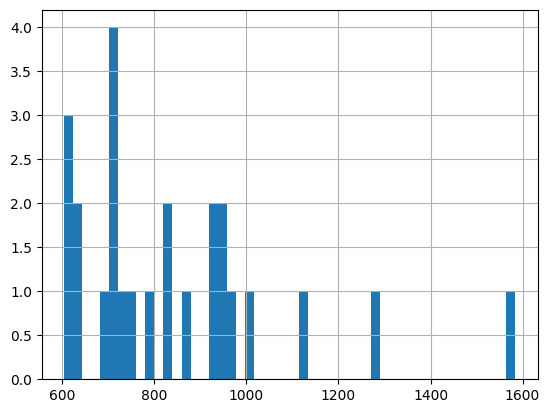

In [28]:
# zoom into the right tail - "Arrival Delay in Minutes"
data[data["Arrival Delay in Minutes"] > 600]["Arrival Delay in Minutes"].hist(bins=50)
plt.show()

Again, as small-frequency bins are visible, we can see that the tails are almost smooth, no extreme isolated spikes.

**Inspect Top Values Directly:**

In [29]:
# inspect top values - "Departure Delay in Minutes"
data["Departure Delay in Minutes"].sort_values(ascending=False).head(20).to_list()

[1592,
 1305,
 1128,
 1017,
 978,
 951,
 933,
 930,
 921,
 859,
 853,
 815,
 794,
 756,
 750,
 748,
 729,
 726,
 724,
 692]

In [30]:
# inspect top values - "Arrival Delay in Minutes"
data["Arrival Delay in Minutes"].sort_values(ascending=False).head(20).to_list()

[1584,
 1280,
 1115,
 1011,
 970,
 952,
 940,
 924,
 920,
 860,
 823,
 822,
 795,
 748,
 729,
 720,
 717,
 705,
 702,
 691]

The skew seems to be gradual and natural, no extremely isolated spikes. 
In addition, large delay values may be realistic, heavy right-skew is expected. Delays are operational events, not measurement errors. 

Therefore, we will keep them, no outlier treatment will be applied to these variables.

## 3. Exploratory Data Analysis (EDA):

### 3.1. Inspect the Target Variable - Satisfaction:

We will inspect the unique values of the satisfaction variable, and the distribution between these values.

In [31]:
# find the proportions between satisfaction levels
data["satisfaction"].value_counts(normalize=True)

satisfaction
satisfied                  0.547328
neutral or dissatisfied    0.452672
Name: proportion, dtype: float64

We can see that there are two unique values of the satisfaction variable - "satisfied" and "neutral or dissatisfied", with a distribution of ~55% and ~45%, respectively.

### 3.2. Inspect the Statistics of Rating Columns: 
For convenience, we will sort them by the means. Since ratings of 0 mean "Not Applicable", we should inspect the statistics of the non-zero ratings separately, because the zeroes affect important measures, such as mean, median, standard deviation, etc.

In [32]:
# inspect the statistics of rating columns, sorted by mean, excluding the ratings of 0
rating_describe = data[rating_cols][data[rating_cols] > 0].describe().sort_values(axis=1, by="mean")
rating_describe

,Seat comfort,Food and drink,Gate location,Departure/Arrival time convenient,Inflight wifi service,Checkin service,Online boarding,Inflight entertainment,On-board service,Ease of Online booking,Leg room service,Online support,Baggage handling,Cleanliness
count,125083.000000,123935.000000,129878.000000,123216.000000,129748.000000,129879.000000,129866.000000,126902.000000,129875.000000,129862.000000,129436.000000,129879.000000,129880.000000,129875.000000
mean,2.947459,2.988801,2.990468,3.152391,3.252435,3.340833,3.352948,3.462877,3.465209,3.472586,3.497860,3.519730,3.695673,3.705902
std,1.301518,1.332460,1.305927,1.395948,1.315408,1.260553,1.298318,1.256758,1.270678,1.305010,1.278182,1.306479,1.156483,1.151567
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,2.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


We see that the means of the three lowest rating variables, are ~2.9-3.0. The means of the few highest rating variables are ~3.5-3.7. 

We also see that the standard deviations of all the rating variables are similar, with values of ~1.15-1.4. 

It seems that the largest difference between means is about a half of the typical standard deviation, so the difference between the means has weak significance.

We will investigate more which columns to focus on, in the advanced analysis section.

### 3.3. Inspect the Statistics of Non-Rating Numeric Columns: 

In [33]:
# inspect the statistics of non-rating numeric columns
data[non_rating_numeric_cols].describe()

,Age,Flight Distance,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.0
mean,39.427957,1981.409055,14.713713,15.045465
std,15.119360,1027.115606,38.071126,38.416353
min,7.000000,50.000000,0.000000,0.0
25%,27.000000,1359.000000,0.000000,0.0
50%,40.000000,1925.000000,0.000000,0.0
75%,51.000000,2544.000000,12.000000,13.0
max,85.000000,6951.000000,1592.000000,1584.0


We can see that the age is quite normally distributed (see the histogram in the data cleaning section, dealing with outliers - 2.4.).

We also see that the flight distance is right-skew distributed, but not extremely like the delays. Maybe we would like to do comperative analysis later, depending on the flight distance.

We want to check what is the percentage of very large delays, because the max value is huge, and the 75th percentile is quite small, and we do not know where the very large values begin.

In [34]:
# inspect all the percentiles from 75 to 100 (inclusive)
data[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].quantile(np.arange(75, 101)/100)

,Departure Delay in Minutes,Arrival Delay in Minutes
0.75,12.0,13.0
0.76,13.0,14.0
0.77,14.0,15.0
0.78,16.0,16.0
0.79,17.0,18.0
0.80,19.0,19.0
0.81,20.0,21.0
0.82,22.0,22.0
0.83,24.0,24.0
0.84,26.0,26.0


We see that the distributions of both delay variables are similar, so it seems that the only the departure delay has a major effect on the arrival delay, suggesting there were no significant changes in flights duration. We also see that only ~7% of the flights have delays of more than one hour, so there is not much to gain from analyzing this group of passengers further.

### 3.4. Proportions Between Categories in Catecorical Columns:
We have also defined the list of categorical columns, within the data cleaning section. 

**Find proportions between categories, within each catecgorical column:**

In [35]:
# find proportions between categories, within each catecgorical column
props = (
    data[categorical_cols]
      .melt(var_name="variable", value_name="category")
      .groupby("variable")["category"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)

props

,variable,category,proportion
0,Class,Business,0.478596
1,Class,Eco,0.448945
2,Class,Eco Plus,0.072459
3,Customer Type,Loyal Customer,0.816908
4,Customer Type,disloyal Customer,0.183092
5,Gender,Female,0.507384
6,Gender,Male,0.492616
7,Type of Travel,Business travel,0.690584
8,Type of Travel,Personal Travel,0.309416
9,satisfaction,satisfied,0.547328


In the table we have just got as an output, we have:
* The "variable" column, which contains all the categorical column names from our data.
* The "category" column, with all the unique values of each categorical column from our data.
* The "proportion" column, which shows the distribution of all the observations in our data, between the unique values ("category") of each categorical column ("variable"). For each categorical column seperately, the proportions summarize to 1.

## 4. Advanced Analysis:

### 4.1. Correlation Analysis:

Create a copy of the data, so we can specifically edit the copy for our correlation analysis needs:

In [36]:
# Create a copy of the data
data_clean = data.copy()

Replace al the zero ratings in the copy of the data with nan, so the correlation analysis ignores them:

In [37]:
# replace al the zero ratings in the copy of the data with nan, so the correlation analysis ignores them
data_clean[rating_cols] = data_clean[rating_cols].replace(0, np.nan)

Create a correlation matrix, between all numeric columns:

In [38]:
# create a correlation matrix, between all numeric columns
corr_matrix = data_clean.corr(numeric_only=True)

Slice the correlation matrix, so we only get correlations between rating columns:

In [39]:
# slicing the correlation matrix, so we only get correlations between rating columns
result_r = corr_matrix.loc[rating_cols, rating_cols]
result_r

,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding
Seat comfort,1.000000,0.491012,0.674270,0.438258,0.139785,0.428103,0.136670,0.211663,0.121383,0.116263,0.108622,0.060255,0.099167,0.145563
Departure/Arrival time convenient,0.491012,1.000000,0.618845,0.612858,-0.013617,0.059735,-0.026208,-0.032909,0.060679,0.006852,0.066847,0.083907,0.067327,-0.014206
Food and drink,0.674270,0.618845,1.000000,0.581389,0.020368,0.323806,0.025765,0.016477,0.025708,0.036888,0.014097,0.022316,0.014315,0.010130
Gate location,0.438258,0.612858,0.581389,1.000000,-0.004354,-0.006539,0.002953,0.001520,-0.025125,-0.007753,-0.000483,-0.031840,-0.001692,-0.002934
Inflight wifi service,0.139785,-0.013617,0.020368,-0.004354,1.000000,0.268956,0.558245,0.602534,0.060341,0.034710,0.038471,0.091856,0.037403,0.632855
Inflight entertainment,0.428103,0.059735,0.323806,-0.006539,0.268956,1.000000,0.460861,0.332735,0.195768,0.164834,0.128684,0.245984,0.121683,0.375775
Online support,0.136670,-0.026208,0.025765,0.002953,0.558245,0.460861,1.000000,0.617723,0.157925,0.141957,0.102434,0.206780,0.095653,0.669994
Ease of Online booking,0.211663,-0.032909,0.016477,0.001520,0.602534,0.332735,0.617723,1.000000,0.436164,0.356537,0.398366,0.137618,0.417564,0.684176
On-board service,0.121383,0.060679,0.025708,-0.025125,0.060341,0.195768,0.157925,0.436164,1.000000,0.413847,0.530406,0.250848,0.551145,0.139421
Leg room service,0.116263,0.006852,0.036888,-0.007753,0.034710,0.164834,0.141957,0.356537,0.413847,1.000000,0.411217,0.169452,0.411600,0.113760


Slice the correlation matrix, so we only get correlations between non-rating numeric columns as rows, and rating columns as columns:

In [40]:
# slice the correlation matrix, so we only get correlations between non-rating numeric columns as rows, 
# and rating columns as columns
result_n = corr_matrix.loc[non_rating_numeric_cols, rating_cols]
result_n

,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding
Age,0.001162,-0.009529,0.006259,-0.000529,0.012765,0.105530,0.121211,0.071407,0.066803,0.091583,-0.015452,0.031852,-0.018170,0.037689
Flight Distance,-0.056660,-0.015391,-0.021508,-0.002408,0.014078,-0.035387,-0.032024,-0.021964,-0.032350,-0.039059,0.019768,0.002455,0.009692,0.009739
Departure Delay in Minutes,-0.035892,-0.002160,-0.020788,0.003948,-0.025831,-0.042482,-0.033921,-0.036584,-0.037685,0.002172,-0.009985,-0.020799,-0.062193,-0.019940
Arrival Delay in Minutes,-0.038055,-0.003865,-0.022617,0.003606,-0.028093,-0.045756,-0.035828,-0.039785,-0.041408,-0.001047,-0.014212,-0.023730,-0.067104,-0.021663


Visualize the correlations between rating columns:

<Axes: >

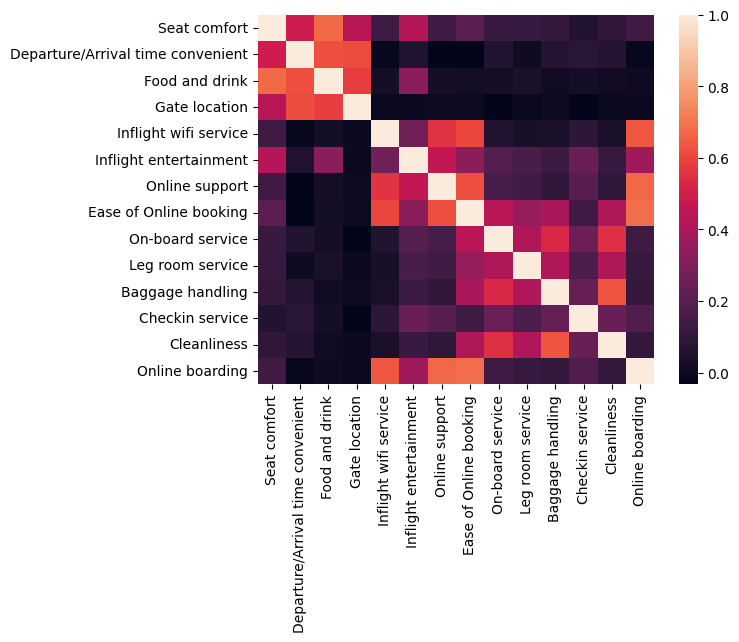

In [41]:
# visualize the correlations between rating columns
corr_map = sns.heatmap(result_r)
corr_map

We see that some rating columns are correlated moderately to strongly between themselves, and very weakly to the others. 

We want to see this as groups, or blocks, so it would be more clear to understand which variables are more correlated between themselves, so we change the order of the rating columns (in the copy of the data that has been created especially for correlation analysis). 

In [42]:
# re-order the list of rating columns, and re-create the correlation matrix
new_order_rating_cols_list = [ 
 'Departure/Arrival time convenient',
 'Gate location',
 'Seat comfort',
 'Food and drink',
 'Inflight entertainment',
 'Inflight wifi service',
 'Online support',
 'Online boarding',
 'Ease of Online booking',
 'Leg room service',
 'Baggage handling',
 'Cleanliness',
 'On-board service',
 'Checkin service'
 ]
data_clean.replace(rating_cols, new_order_rating_cols_list)
new_corr_rating_matrix = data_clean.corr(numeric_only=True).loc[new_order_rating_cols_list, new_order_rating_cols_list]

Visualize the correlations between rating columns, in their new order:

<Axes: >

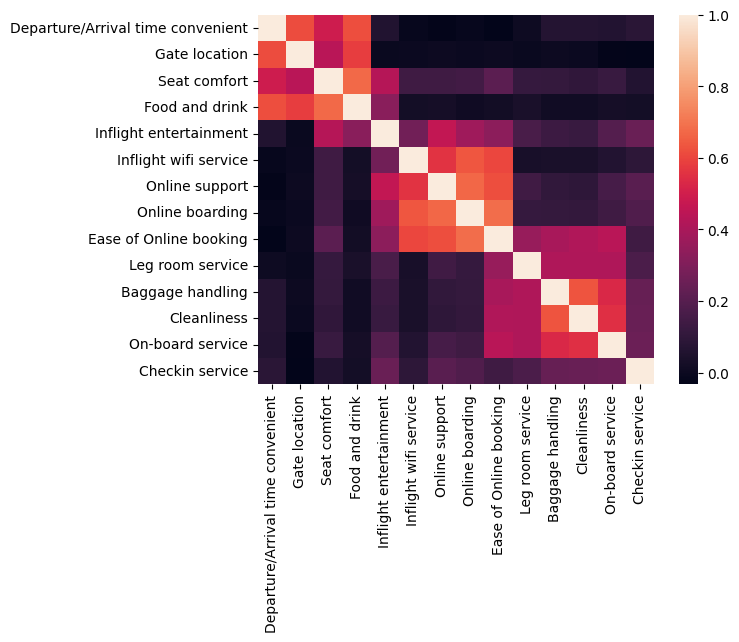

In [43]:
# visualize the correlations between rating columns, in their new order
corr_map = sns.heatmap(new_corr_rating_matrix)
corr_map

We see, in the correlation map above, that there are a few groups of rating variables, that have moderate to strong correlations within themself, and very weak correlations with others. Some of the groups have one or two common variables. The groups are: 
1. ['Departure/Arrival time convenient', 'Gate location', 'Seat comfort', 'Food and drink']
2. ['Seat comfort', 'Food and drink', 'Inflight entertainment']
3. ['Inflight entertainment', 'Inflight wifi service', 'Online support', 'Online boarding', 'Ease of Online booking']
4. ['Ease of Online booking', 'Leg room service', 'Baggage handling', 'Cleanliness', 'On-board service']
5. ['Checkin service']

There are two variables, 'Seat comfort' and 'Food and drink', which are common between groups 1 and 2. There is also one variable, 'Inflight entertainment', which is common between groups 2 and 3. There is also one variable, 'Ease of Online booking', which is common between groups 3 and 4.

Please note:
- Group 1 consists of variables related to physical convenience.
- Group 2 consists of variables related to covenience while on the flight.
- Group 3 consists of variables related to user interface topics, except for 'Checkin service'.
- Group 4 consists of variables related to services before and during the flight.
- Group 5 is a single variable, 'Checkin service', which is not significantly correlated to any of the others.

### 4.2. Inspect All Columns - Conditional on Satisfaction:

#### Categorical Columns:

We want to calculate the distributions of categorical columns, for the whole data, and for the two subsets of satisfied and dissatisfied customers.

We also want to calculate, for each column: 
- The difference between the satisfied and dissatisfied distributions.
- The same difference, but normalized by the column distribution for the whole data (relative probability difference).
- The sum of absolute values of relative probability difference, between the satisfied and dissatisfied distributions. The larger this sum for a specific column, the more related is this column, to the difference between the satisfied and dissatisfied customers.

In [44]:
"""define a function, that gets two arguments - 
a data frame, and a list of names of some of its columns. 
The function returns a dictionary, with: 
the column names in the list given as the second argument, as keys; 
for each column name in that list, the value is an inner dictionary, 
of some useful statistical distributions, 
between categories and conditions on satisfaction."""

def col_distrib_by_satisfaction(df, cols):
    is_satisfied = df["satisfaction"] == "satisfied"
    
    p_col = {col: df[col].value_counts(normalize=True).sort_index() for col in cols}
    p_col_s_true = {col: df.loc[is_satisfied ,col].
                     value_counts(normalize=True).sort_index() for col in cols}
    p_col_s_false = {col: df.loc[~is_satisfied ,col].
                     value_counts(normalize=True).sort_index() for col in cols}
    p_col_diff = {col: p_col_s_true[col] - p_col_s_false[col] for col in cols}
    p_col_rel_diff = {col: p_col_diff[col] / p_col[col] for col in cols}
    p_col_tot_diff = {col: np.sum(np.abs(p_col_diff[col])) for col in cols}
    output = {col: {
        "p_col": p_col[col],
        "p_col_s_true": p_col_s_true[col],
        "p_col_s_false": p_col_s_false[col],
        "p_col_diff": p_col_diff[col],
        "p_col_rel_diff": p_col_rel_diff[col],
        "p_col_tot_diff": p_col_tot_diff[col]
        } for col in cols}
    return output

categorical_cols_excl_satisfaction = \
[col for col in categorical_cols if col != "satisfaction"]

categorical_distrib_by_satisfaction = col_distrib_by_satisfaction\
(data, categorical_cols_excl_satisfaction)

print(categorical_distrib_by_satisfaction)

{'Gender': {'p_col': Gender
Female    0.507384
Male      0.492616
Name: proportion, dtype: float64, 'p_col_s_true': Gender
Female    0.60388
Male      0.39612
Name: proportion, dtype: float64, 'p_col_s_false': Gender
Female    0.39071
Male      0.60929
Name: proportion, dtype: float64, 'p_col_diff': Gender
Female    0.21317
Male     -0.21317
Name: proportion, dtype: float64, 'p_col_rel_diff': Gender
Female    0.420136
Male     -0.432730
Name: proportion, dtype: float64, 'p_col_tot_diff': np.float64(0.4263399492075356)}, 'Customer Type': {'p_col': Customer Type
Loyal Customer       0.816908
disloyal Customer    0.183092
Name: proportion, dtype: float64, 'p_col_s_true': Customer Type
Loyal Customer       0.919817
disloyal Customer    0.080183
Name: proportion, dtype: float64, 'p_col_s_false': Customer Type
Loyal Customer       0.69248
disloyal Customer    0.30752
Name: proportion, dtype: float64, 'p_col_diff': Customer Type
Loyal Customer       0.227336
disloyal Customer   -0.227336
Name

Visualize the sum of absolute values of difference, between satisfied and dissatisfied customers, for each categorical column, except for the "satisfaction" column. 

Reminder:  The larger this sum for a specific column, the more related is this column to the difference between the satisfied and dissatisfied customers.

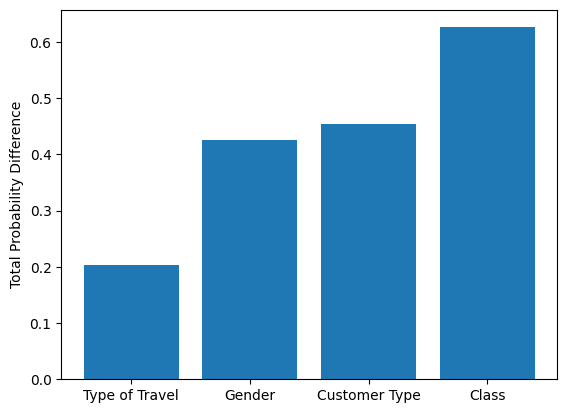

In [45]:
# visualize the total differences between satisfied and dissatisfied customers, 
# for each categorical column, except for "satisfaction"
categories_to_plot = pd.DataFrame({col: categorical_distrib_by_satisfaction[col]["p_col_tot_diff"] 
                           for col in categorical_cols_excl_satisfaction},
                           index=["value"]).transpose()
categories_to_plot_sorted_by_value = categories_to_plot.sort_values(by="value")
plt.bar(categories_to_plot_sorted_by_value.index, categories_to_plot_sorted_by_value["value"])
plt.ylabel("Total Probability Difference")
plt.show()

Define a function for plotting the difference between the satisfied and dissatisfied customers, for a given categorical column (excluding "satisfaction"), normalized by the column distribution for the whole data - relative probability difference. Please note: positive bars (differences) mean that in the corresponding category, there were more satisfied than dissatisfied customers; negative bars (differences) mean the opposite.

These differences are an indication, that if we want to investigate the reasons for dissatisfaction, we should focus in analyzing data of customers in the large-difference negative bar categories, rather than the other categories.

In [46]:
"""define a function, that gets one argument - a certain categorical column, and plots the 
relative probability difference, for each category in that ctegorical column."""
def plot_category_rel_diff(col):
    categories = categorical_distrib_by_satisfaction[col]["p_col_rel_diff"]
    categories_to_plot = pd.DataFrame({"Name": categories.sort_index().index.to_list(), 
                                    "Value": categories.sort_index().values})
    categories_to_plot_sorted_by_value = categories_to_plot.sort_values(by="Value")
    plt.bar(categories_to_plot_sorted_by_value["Name"], categories_to_plot_sorted_by_value["Value"])
    plt.axhline(y=0, color='black', linewidth=1)
    plt.ylabel("Relative Probability Difference")
    plt.show()

We will now call the function, for each of the three columns, with the largest total probability differences. 

Reminder: The larger this total difference for a specific column, the more related is this column to the difference between the satisfied and dissatisfied customers.

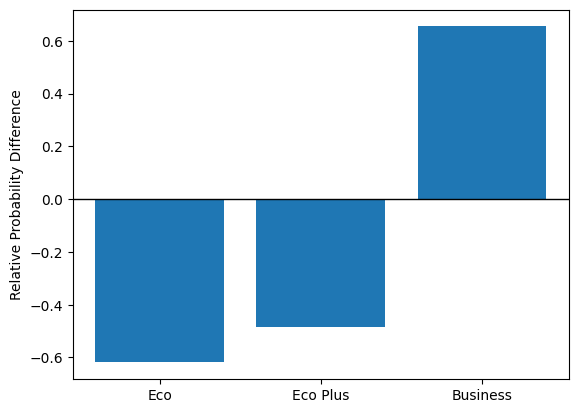

In [47]:
# call the function for the "Class" column
plot_category_rel_diff("Class")

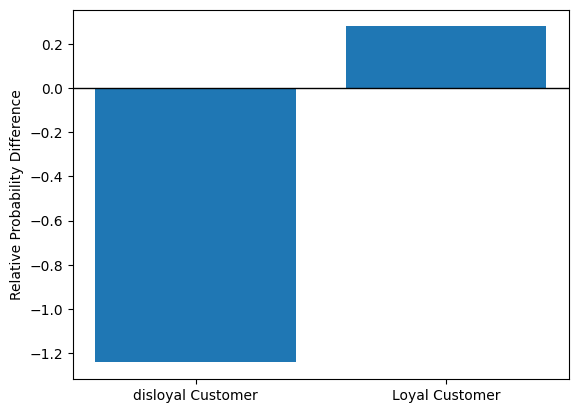

In [48]:
# call the function for the "Customer Type" column
plot_category_rel_diff("Customer Type")

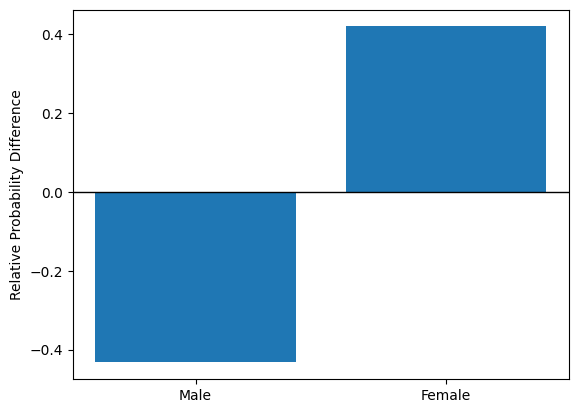

In [49]:
# call the function for the "Gender" column
plot_category_rel_diff("Gender")

**From the three bar plots above:** 
For the "Class" column, we can see that the portion of the "Eco" category, from satisfied customers, is much smaller than the portion of the "Eco" category, from dissatisfied customers. Similarly for "Eco Plus". On the other hand, for "Business", the situation is the opposite - the portion from satisfied customers, is much larger than the portion from dissatisfied customers. This is an indication that if we want to investigate the reasons for dissatisfaction, we should focus in analyzing data of customers in the "Eco" and "Eco Plus" categories, rather than the "Business" category. 
Similarly, for the "Customer Type" column, we can see that most of the disloyal customers are dissatisfied, while most of the loyal customers are satisfied. 
For the "Gender" column, we can see that most of the male customers are dissatisfied, while most of the female customers are satisfied. 

#### Statistics of Numeric Columns:

We will now inspect meaningful groups of numeric columns - non-rating, and rating, which were previously defined within the data cleaning section.

First, we define two subsets of the whole data - for satisfied and dissatisfied customers:

In [50]:
# define two subsets of the whole data - for satisfied and dissatisfied customers
satisfied_data = data[data["satisfaction"] == "satisfied"]
dissatisfied_data = data[data["satisfaction"] != "satisfied"]

We also define utility lambda functions:

In [51]:
# define utility lambda functions
mean_cols = lambda df, cols: df[df[cols] > 0][cols].mean()
std_cols = lambda df, cols: df[df[cols] > 0][cols].std()
group_size_cols = lambda df, cols: df[df[cols] > 0][cols].shape[0]

**Non-Rating Numeric Columns:**

The non-rating numeric columns are:
- Age (characterizes the passenger)
- Flight Distance, Departure Delay in Minutes, and Arrival Delay in Minutes (characterize the flight)

We calculate and plot the normalized difference between means, of the satisfied subset and dissatisfied subset. The normalization is by the joint spread of the two subsets, which is calculated by the square root of the sum of the variances.

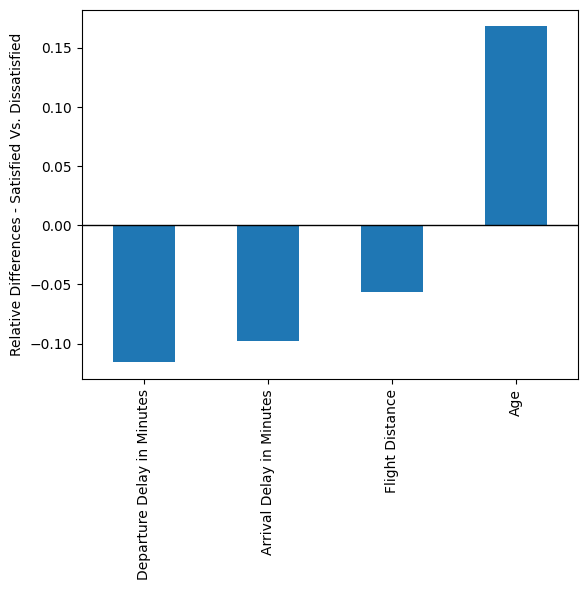

In [52]:
"""calculate and plot the normalized difference between means, 
of the satisfied subset and dissatisfied subset. 
the normalization is by the joint spread of the two subsets, 
which is calculated by the square root of the sum of the variances"""
diff_non_ratings = ((mean_cols(satisfied_data, non_rating_numeric_cols) - \
mean_cols(dissatisfied_data, non_rating_numeric_cols)) / \
(std_cols(satisfied_data, non_rating_numeric_cols)**2 + \
std_cols(dissatisfied_data, non_rating_numeric_cols)**2)**0.5)\
.sort_values()
ax_mean_non_rating_diff = diff_non_ratings.plot(kind="bar")
ax_mean_non_rating_diff.axhline(y=0, color='black', linewidth=1)
ax_mean_non_rating_diff.set_ylabel("Relative Differences - Satisfied Vs. Dissatisfied")
plt.show()

We see that the mean age of satisfied customers, is higher than the mean age of dissatisfied customers, but not by much, relative to the spread of ages in each group. 

The other three variables, which describe properties of the flight, show a weak negative relationship, between these variables and satisfaction.

Therefore, we do not have much to gain from analyzing these variables further.

**Rating Columns:**

Calculate and plot the mean rating differences between satisfied and dissatisfied customers, in order to understand which rating variables, have the most impact on overall satisfaction, compared to other rating variables.

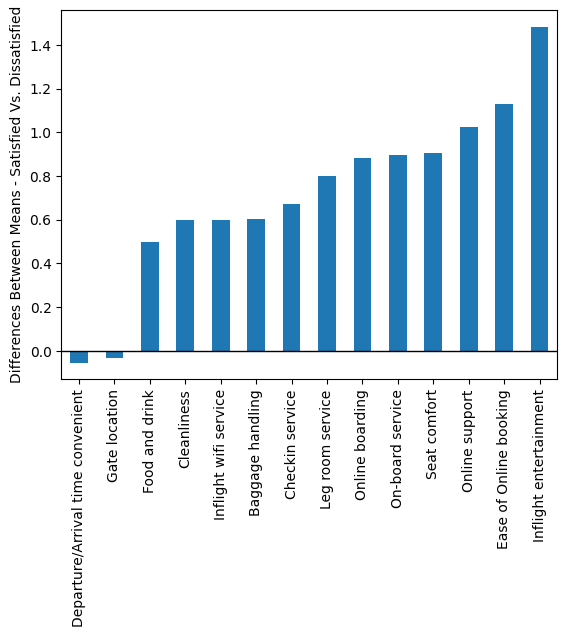

In [53]:
# calculate and plot the mean rating differences between satisfied and dissatisfied customers
diff_ratings = (mean_cols(satisfied_data, rating_cols) - mean_cols(dissatisfied_data, rating_cols)).sort_values()
ax_mean_rating_diff = diff_ratings.plot(kind="bar")
ax_mean_rating_diff.axhline(y=0, color='black', linewidth=1)
ax_mean_rating_diff.set_ylabel("Differences Between Means - Satisfied Vs. Dissatisfied")
plt.show()

Perform the Mann–Whitney U test, on each rating column, between two groups of data - for satisfied and dissatisfied customers, excluding ratings of 0. We want to check if the difference between the two groups is statistically significant (not to be confused with practical significance) - by getting the probability (the second returned value), that both groups of data, have been drawn from the same original distribution. If that probability is below the threshold of 0.05, then the difference between the two groups of data is considered as statistically significant.

Mann–Whitney U test, is the standard test for comparing two independent groups, on ordinal/numeric data.

That does not neccessarily mean that the difference is practically significant (test and explanation - see in the next step). 

In [54]:
# Perform the Mann–Whitney U test, on each rating column, between two groups of data - 
# for satisfied and dissatisfied customers, excluding ratings of 0

dict_rbc = {}
for col in rating_cols:
    group_satisfied_col = satisfied_data[col][satisfied_data[col] > 0]
    group_dissatisfied_col = dissatisfied_data[col][dissatisfied_data[col] > 0]    
    u, p = mannwhitneyu(group_satisfied_col, group_dissatisfied_col, alternative="two-sided")
    n1 = len(group_satisfied_col)
    n2 = len(group_dissatisfied_col)
    rbc_ = (2 * u) / (n1 * n2) - 1
    dict_rbc[col] = rbc_
    print(col + ": p = " + str(p) + ", rbc_ = " + str(rbc_))

series_rbc = pd.Series(dict_rbc).sort_values()
print(series_rbc)

Seat comfort: p = 0.0, rbc_ = 0.3898121115705131
Departure/Arrival time convenient: p = 1.0085241507821518e-09, rbc_ = -0.0197563008648739
Food and drink: p = 0.0, rbc_ = 0.21170030090880387
Gate location: p = 9.327738968531026e-06, rbc_ = -0.013941601070430854
Inflight wifi service: p = 0.0, rbc_ = 0.25213350255699907
Inflight entertainment: p = 0.0, rbc_ = 0.6921852236960557
Online support: p = 0.0, rbc_ = 0.45210553189341085
Ease of Online booking: p = 0.0, rbc_ = 0.48341818019109795
On-board service: p = 0.0, rbc_ = 0.4020270825062997
Leg room service: p = 0.0, rbc_ = 0.3513785704750141
Baggage handling: p = 0.0, rbc_ = 0.31941810363901446
Checkin service: p = 0.0, rbc_ = 0.2938436505054476
Cleanliness: p = 0.0, rbc_ = 0.31549476858321523
Online boarding: p = 0.0, rbc_ = 0.37653745910215486
Departure/Arrival time convenient   -0.019756
Gate location                       -0.013942
Food and drink                       0.211700
Inflight wifi service                0.252134
Checkin se

A Mann–Whitney U test revealed a statistically significant difference in all rating columns, between satisfied and dissatisfied passengers (p<0.05). 

Now we want to check if the differences between both groups - satisfied and dissatisfied (checked for each rating column), are practically significant. Practical significance means that the difference actually matters - large enough to matter for decisions. For this purpose, we can calculate Rank-Biserial Correlation. This metric indicates how likely are values from the first group, to be larger than the second group.

The meaning of the result of that RBC metric, which can get any value between (-1) and (+1), is: 
- |RBC|=~0.1 means small.
- |RBC|=~0.3 means medium.
- |RBC|=~0.5+ means large.

A larger absolute value of that RBC metric, means a larger importance of the corresponding rating variable, for the overall satisfaction of customers. The sign of RBC, in our context, indicates which of the two groups - satisfied and dissatisfied customers, is more likely to rate that variable higher. A positive value of RBC means, that satisfied customers tend to rate the corresponding rating variable higher than dissatisfied customers, and the opposite for a negative RBC value.

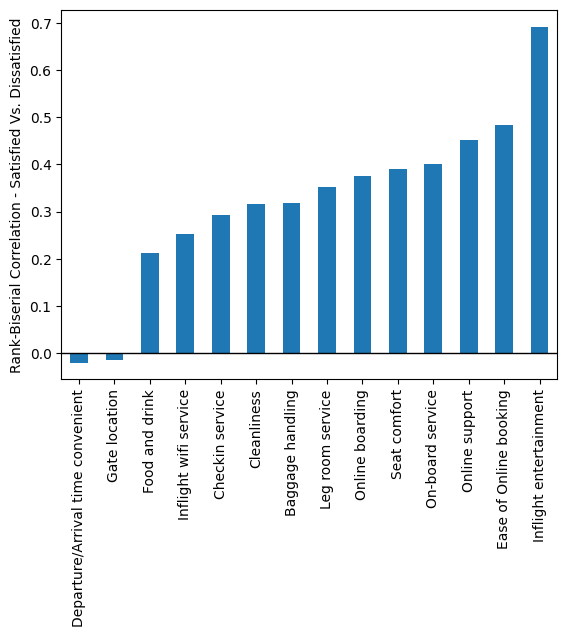

In [55]:
# visualize our findings from the Mann–Whitney U test
ax_rbc = series_rbc.plot(kind="bar")
ax_rbc.axhline(y=0, color='black', linewidth=1)
ax_rbc.set_ylabel("Rank-Biserial Correlation - Satisfied Vs. Dissatisfied")
plt.show()

We see that the "Inflight entertainment" column got the highest and positive RBC value, and much higher than the value for any other rating column, suggesting that the "Inflight entertainment" variable is the most important for customers' overall satisfaction.

The "Departure/Arrival time convenient" and "Gate location" variables got RBC values which are very close to zero, suggesting that these variables hardly impact the overall satisfaction of customers, so probably they are the least important for customers' overall satisfaction.

The rest of the rating variables got small-medium to medium-large positive RBC values, suggesting that they have some impact on overall satisfaction of customers, but much less than the "Inflight entertainment" variable.

In [56]:
# define the rating groups from the correlation analysis section
physical_convenience = ['Departure/Arrival time convenient', 'Gate location', 'Seat comfort', 'Food and drink']
in_flight_covenience = ['Seat comfort', 'Food and drink', 'Inflight entertainment']
user_interface = ['Inflight entertainment', 'Inflight wifi service', 'Online support', 'Online boarding', 'Ease of Online booking']
flight_service = ['Ease of Online booking', 'Leg room service', 'Baggage handling', 'Cleanliness', 'On-board service']
checkin_service = ['Checkin service']

# name the groups and collect them into a dictionary
rating_groups = {"Physical convenience": physical_convenience, 
                 "In Flight Covenience": in_flight_covenience,"User Interface": user_interface, 
                 "Flight Service": flight_service, "Checkin Service": checkin_service}

# collect the rbc values of all the rating columns, group them by the above groups and
# collect them into another dictionary
rbc_by_groups = {group: series_rbc.loc[rating_groups[group]] for group in rating_groups}    

# create a dictionary of the groups and their mean and std features
rbc_by_group_feat = {group: [rbc_by_groups[group].mean(), rbc_by_groups[group].std()] 
                                  for group in rbc_by_groups}
rbc_by_group_feat['Checkin Service'][1] = 0.0

# convert the last dictionary into a data frame
rbc_by_group_feat = pd.DataFrame.from_dict\
(rbc_by_group_feat, orient="index", columns=["rbc_mean", "rbc_std"]).sort_values(by="rbc_mean")

rbc_by_group_feat

,rbc_mean,rbc_std
Physical convenience,0.141954,0.197275
Checkin Service,0.293844,0.000000
Flight Service,0.374347,0.070127
In Flight Covenience,0.431233,0.242906
User Interface,0.451276,0.161489


For the groups of "Flight Service" and "User Interface", the standard deviation is small relative to the mean, suggesting that the variables in them get relatively similar ratings (in satisfied and dissatisfied customers seperately), so it seems that we can gain from analyzing them as groups, rather than one by one.

For the groups "Physical convenience" and "In Flight Covenience", the standard deviation is large relative to the mean, suggesting that the variables in them get very different ratings, so we might want to analyze them seperately, rather than grouping them together.

The group "Checkin Service" is actually a single variable, so analyzing it will anyway be seperately from the other rating variables.

Now we want to visualize this:

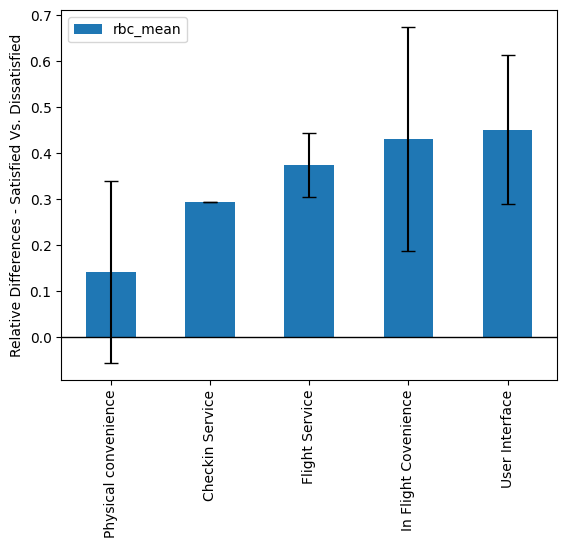

In [57]:
# visualize the above groups with their mean and std features
ax_rbc_by_group_feat = rbc_by_group_feat.plot(kind="bar", y="rbc_mean", yerr="rbc_std", capsize=5)
ax_rbc_by_group_feat.axhline(y=0, color='black', linewidth=1)
ax_rbc_by_group_feat.set_ylabel("Relative Differences - Satisfied Vs. Dissatisfied")
plt.show()

Define a utility lambda function:

In [58]:
# define a utility lambda function
rating_distribution = lambda df, col: df[df[col] > 0][col]\
.value_counts(normalize=True).reindex(range(1,6), fill_value=0)

Define a function for visualizing rating distributions for satisfied and dissatisfied customers, one column each time:

In [59]:
# define a function for visualizing rating distributions for satisfied and dissatisfied 
# customers, one column each time
def plot_rating_distrib(col):
    distrib_satisfied = rating_distribution(satisfied_data, col)
    distrib_dissatisfied = rating_distribution(dissatisfied_data, col)
    distrib_df = pd.DataFrame({"Satisfied": distrib_satisfied, "Dissatisfied": distrib_dissatisfied})
    distrib_df.plot(kind="bar")
    plt.show()

Visualize and inspect such rating distributions, for different columns with different distributions:

For columns with large practically significant differences:

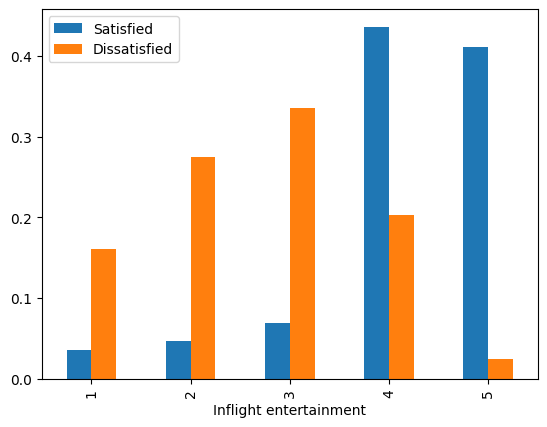

In [60]:
# call the function for the "Inflight entertainment" column
plot_rating_distrib("Inflight entertainment")

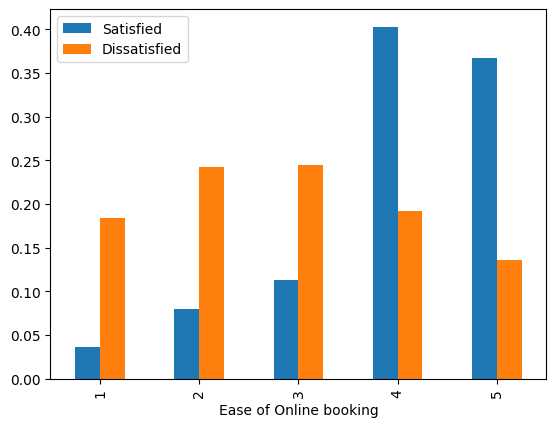

In [61]:
# call the function for the "Ease of Online booking" column
plot_rating_distrib("Ease of Online booking")

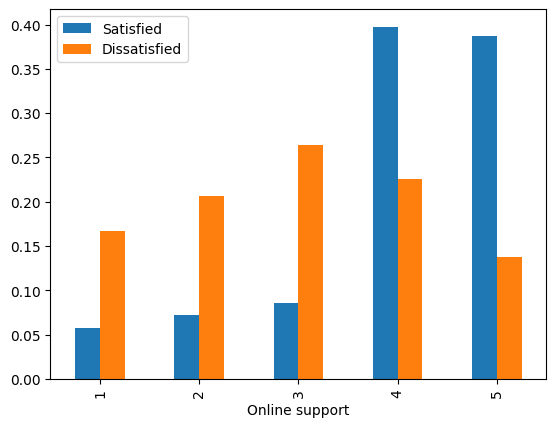

In [62]:
# call the function for the "Online support" column
plot_rating_distrib("Online support")

For columns with small to no practically significant differences:

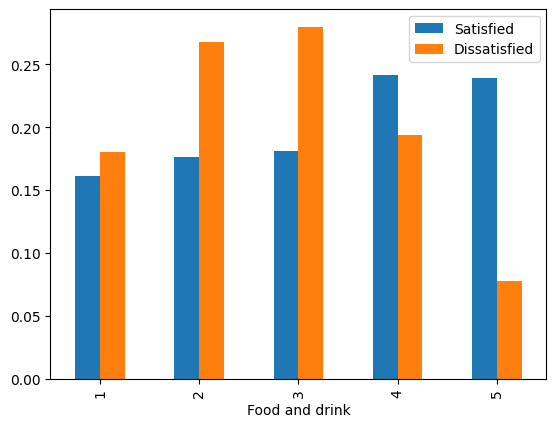

In [63]:
# call the function for the "Food and drink" column
plot_rating_distrib("Food and drink")

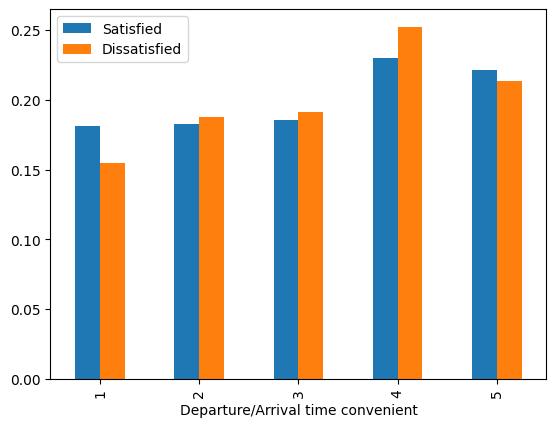

In [64]:
# call the function for the "Departure/Arrival time convenient" column
plot_rating_distrib("Departure/Arrival time convenient")

Define a function for calculating RBC values for all rating column, for a given data frame. The function returns a series, with column names as index and rbc values as values:

In [65]:
"""function: calc_rbc(df, cols) - 
gets a data frame and a list of columns, 
and returns a series, with column names as index and rbc values as values"""
def calc_rbc(df, cols):
    
    satisfied_data = df.loc[df["satisfaction"] == "satisfied"]
    dissatisfied_data = df.loc[df["satisfaction"] != "satisfied"]

    dict_rbc = {}
    for col in cols:
        group_satisfied_col = satisfied_data[col][satisfied_data[col] > 0]
        group_dissatisfied_col = dissatisfied_data[col][dissatisfied_data[col] > 0]    
        u, p = mannwhitneyu(group_satisfied_col, group_dissatisfied_col, alternative="two-sided")
        n1 = len(group_satisfied_col)
        n2 = len(group_dissatisfied_col)
        rbc_ = (2 * u) / (n1 * n2) - 1
        dict_rbc[col] = rbc_

    return pd.Series(dict_rbc)

We want to split the whole data into subsets, by the categories within one categorical variable (column) at a time, then visualize and compare their RBC values, to check which rating variables makes larger practically significant differences between satisfied and dissatisfied customers, for each of the categories for splitting the data.

Splitting the data by the "Class" variable:

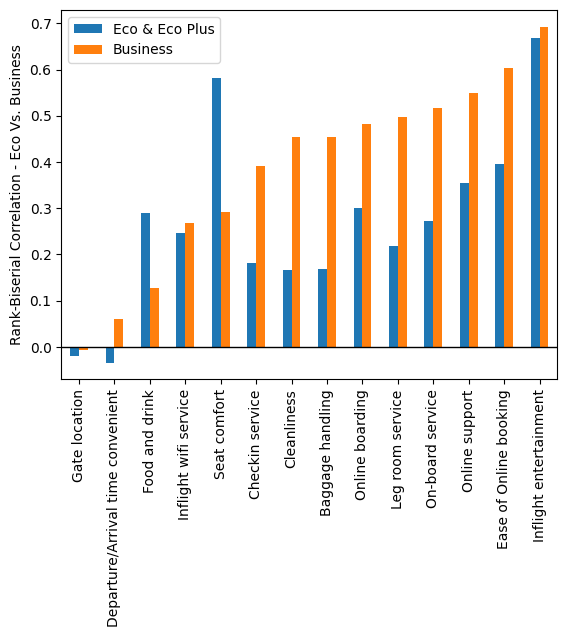

In [66]:
# define a subset of the whole data, where the value of the "Class" column is "Eco" or 
# "Eco Plus", and calculate the rbc values of the ratings in this subset
filtered_df_eco = data.loc[(data["Class"] == "Eco") | (data["Class"] == "Eco Plus")]
rbc_eco = calc_rbc(filtered_df_eco, rating_cols).sort_values()

# define a subset of the whole data, where the value of the "Class" column is "Business", 
# and calculate the rbc values of the ratings in this subset
filtered_df_business = data.loc[data["Class"] == "Business"]
rbc_business = calc_rbc(filtered_df_business, rating_cols).sort_values()

# collect the above rbc values into a data frame
rbc_by_class = pd.DataFrame({"Eco & Eco Plus": rbc_eco, "Business": rbc_business}
                           ).sort_values(by="Business")
# visualize the information from the above data frame
ax = rbc_by_class.plot(kind="bar")
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylabel("Rank-Biserial Correlation - Eco Vs. Business")
plt.show()

From the bar plot above, we can see that:
- The variable of "Inflight entertainment" has large RBC values for all categories within the "Class" variable, suggesting that inflight entertainment makes large practically significant differences between satisfied and dissatisfied customers, for all classes (categories).
- The variable of "Inflight wifi service" has medium RBC values for all categories within the "Class" variable, suggesting that inflight wifi service makes medium practically significant differences between satisfied and dissatisfied customers, for all classes (categories).
- The variables of "Gate location" and "Departure/Arrival time convenient" have very small RBC values for all classes, suggesting that gate location and departure/arrival time convenience make small to no practically significant differences between satisfied and dissatisfied customers, for all classes.
- The variables of "Seat comfort" and "Food and drink" have relatively much larger RBC values for the "Eco" and "Eco Plus" classes, compared to the "Business" class, suggesting that both of these rating variables make much larger practically significant differences between satisfied and dissatisfied customers in the "Eco" and "Eco Plus" classes, compared to the "Business" class. It also seems that the seat comfort has higher RBC values and makes larger practically significant differences between satisfied and dissatisfied customersfor all classes, compared to the food and drink.
- The rest of the rating variables, have relatively much larger RBC values for the "Business" class, compared to the "Eco" and "Eco Plus" classes, suggesting that all of these rating variables make much larger practically significant differences between satisfied and dissatisfied customers in the "Business" class, compared to the "Eco" and "Eco Plus" classes.

Here are my main practical conclusions:
- The most significant reason for overall dissatisfaction is "Inflight entertainment", for all classes ("Eco", "Eco Plus" and "Business"), so improvement in this is more likely to change customers overall sentiment from dissatisfied to satisfied.
- For "Eco" and "Eco Plus" customers, improvement in seat comfort and/or food and drink is more likely to change their overall sentiment from dissatisfied to satisfied (compared to "Business" customers).
- For "Business" customers, improvement in one or more of the following: ["Ease of Online booking", "Online support", "On-board service", "Leg room service", "Online boarding", "Baggage handling", "Cleanliness", "Checkin service"], is more likely to change customers overall sentiment from dissatisfied to satisfied (compared to "Eco" and "Eco Plus" customers).

Splitting the data by the "Customer Type" variable:

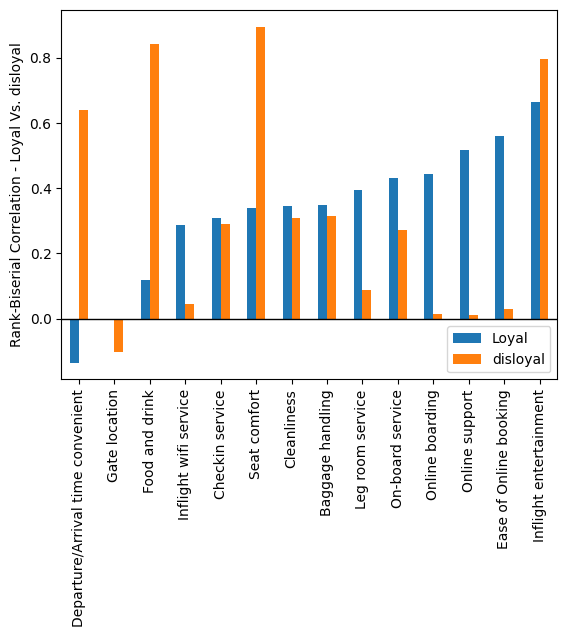

In [67]:
# define a subset of the whole data, where the value of the "Customer Type" column is 
# "Loyal Customer", and calculate the rbc values of the ratings in this subset
filtered_df_loyal = data.loc[data["Customer Type"] == "Loyal Customer"]
rbc_loyal = calc_rbc(filtered_df_loyal, rating_cols).sort_values()

# define a subset of the whole data, where the value of the "Customer Type" column is 
# "disloyal Customer", and calculate the rbc values of the ratings in this subset
filtered_df_disloyal = data.loc[data["Customer Type"] == "disloyal Customer"]
rbc_disloyal = calc_rbc(filtered_df_disloyal, rating_cols).sort_values()

# collect the above rbc values into a data frame
rbc_by_customer_type = pd.DataFrame({"Loyal": rbc_loyal, "disloyal": rbc_disloyal}).sort_values(by="Loyal")
# visualize the information from the above data frame
ax = rbc_by_customer_type.plot(kind="bar")
ax.axhline(y=0, color='black', linewidth=1)
ax.set_ylabel("Rank-Biserial Correlation - Loyal Vs. disloyal")
plt.show()

From the bar plot above, we can see that:
- The variable of "Inflight entertainment" has large RBC values for all categories within the "Customer Type" variable, suggesting that inflight entertainment makes large practically significant differences between satisfied and dissatisfied customers, for all customer types (categories).
- The variable of "Checkin service" has medium RBC values for all categories within the "Customer Type" variable, suggesting that checkin service makes medium practically significant differences between satisfied and dissatisfied customers, for all customer types (categories).
- The variable of "Gate location" has small RBC values for all categories within the "Customer Type" variable, suggesting that gate location makes small to no practically significant differences between satisfied and dissatisfied customers, for all customer types.
- The variables of "Seat comfort", "Food and drink" and "Departure/Arrival time convenient" have relatively much larger RBC values for the "disloyal Customer" customer type, compared to the "Loyal Customer" customer type, suggesting that all the three of these rating variables make much larger practically significant differences between satisfied and dissatisfied customers for disloyal customers, compared to the loyal customers.
- The rest of the rating variables have relatively much larger RBC values for the "Loyal Customer" customer type, compared to the "disloyal Customer" customer type, suggesting that all of these rating variables make much larger practically significant differences between satisfied and dissatisfied customers for the loyal customers, compared to the disloyal customers.

Here are my main practical conclusions:
- The most significant reason for overall dissatisfaction is "Inflight entertainment", for all customer types (loyal and disloyal customers), so improvement in this is more likely to change customers overall sentiment from dissatisfied to satisfied.
- For disloyal customers, improvement in seat comfort and/or food and drink and/or departure/arrival time convenience is more likely to change their overall sentiment from dissatisfied to satisfied (compared to loyal customers).
- For loyal customers, improvement in one or more of the following: ["Ease of Online booking", "Online support", "On-board service", "Leg room service", "Online boarding", "Inflight wifi service"], is more likely to change customers overall sentiment from dissatisfied to satisfied (compared to disloyal customers).

## 5. Main Insights and Recommendations Summary:
- The most significant reason for overall dissatisfaction of all customers is "Inflight entertainment", so improvement in this is more likely to change customers overall sentiment from dissatisfied to satisfied.
- All other rating questions, except for "Departure/Arrival time convenient" and "Gate location", have milder impact on overall satisfaction of customers.
- Male customers tend to be less satisfied overall than female customers.
- "Eco" and "Eco Plus" class customers, tend to be less satisfied overall than "Business" customers. 
- For "Eco" and "Eco Plus" customers, overall satisfaction is more correlated with        "Seat comfort" and "Food and drink", compared to "Business" customers.
- For "Business" customers, overall satisfaction is more correlated with online services and a few more ratings (see detailed list in the "Business" conclusion of 'Splitting the data by the "Class" variable'), compared to "Eco" and "Eco Plus" customers.
- Disloyal customers are less satisfied overall than loyal customers.
- For disloyal customers, overall satisfaction is more correlated with "Seat comfort", "Food and drink" and "Departure/Arrival time convenient", compared to loyal customers.
- For loyal customers, overall satisfaction is more correlated with online services and a few more ratings (see detailed list in the loyal customers conclusion of 'Splitting the data by the "Customer Type" variable'), compared to disloyal customers.
    - My recommendation is to put effort in improving services before the flight and online services (including wifi), especially for loyal customers, in order not to lose them.
- Based on correlation analysis section, we can consider reducing the numbers of similar questions, to simplify the survey for customers without losing significant information.
    - Question group "User Interface": ['Inflight wifi service', 'Online support', 'Online boarding', 'Ease of Online booking'].
    - Question group "Flight Service": ['Ease of Online booking', 'Leg room service', 'Baggage handling', 'Cleanliness', 'On-board service'].